# Diagnosing the gold transformer's training plateau

Training loss barely improved and validation loss stayed flat/noisy over 100 epochs. Before changing anything, this checks the most common, cheapest-to-diagnose explanation: did the model just give up and start predicting close to the average value regardless of input, rather than genuinely responding to each window?

Loads the checkpoint saved by notebook 11 - no retraining needed.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

WINDOW_SIZE = 30

In [2]:
gold = pd.read_csv("../data/gold_futures.csv", skiprows=[1, 2], index_col=0, parse_dates=True)
returns = gold["Close"].pct_change().dropna() * 100


def create_windows(returns, window_size):
    values = returns.values
    X, y, dates = [], [], []
    for start in range(len(values) - window_size):
        end = start + window_size
        X.append(values[start:end])
        y.append(abs(values[end]))
        dates.append(returns.index[end])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32), pd.DatetimeIndex(dates)


X, y, dates = create_windows(returns, WINDOW_SIZE)

n = len(X)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_val, y_val, dates_val = X[train_end:val_end], y[train_end:val_end], dates[train_end:val_end]


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)]


class VolatilityTransformer(nn.Module):
    def __init__(self, d_model=32, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_projection = nn.Linear(1, d_model)
        self.pos_encoding = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=num_heads, dim_feedforward=64, dropout=dropout, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_head = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoding(x)
        x = self.encoder(x)
        last_day = x[:, -1, :]
        out = self.output_head(last_day)
        return nn.functional.softplus(out).squeeze(-1)


checkpoint = torch.load("../models/gold_transformer.pt", weights_only=False)
train_mean = checkpoint["train_mean"]
train_std = checkpoint["train_std"]

model = VolatilityTransformer()
model.load_state_dict(checkpoint["state_dict"])
model.eval()

X_val_norm = (X_val - train_mean) / train_std
X_val_tensor = torch.tensor(X_val_norm, dtype=torch.float32).unsqueeze(-1)

with torch.no_grad():
    predictions = model(X_val_tensor).numpy()

print(f"Number of validation predictions: {len(predictions)}")

Number of validation predictions: 621


## The key numbers: spread of predictions vs. spread of reality

If the model collapsed to "always guess near the average," its predictions' standard deviation will be tiny compared to the real targets' standard deviation.

In [3]:
print(f"Actual targets   -> mean: {y_val.mean():.4f}   std: {y_val.std():.4f}")
print(f"Predictions      -> mean: {predictions.mean():.4f}   std: {predictions.std():.4f}")
print(f"\nPrediction std as % of actual std: {predictions.std() / y_val.std() * 100:.1f}%")

Actual targets   -> mean: 0.6642   std: 0.5875
Predictions      -> mean: 0.6710   std: 0.0546

Prediction std as % of actual std: 9.3%


## Visual checks

1. **Time series**: does the prediction line move with actual volatility, or sit as a flat band?
2. **Distributions**: is the predictions' spread (orange) squeezed compared to reality's (gray)?
3. **Predicted vs. actual scatter**: genuine learning would show an upward trend; a collapsed model shows a flat horizontal band regardless of the true value.

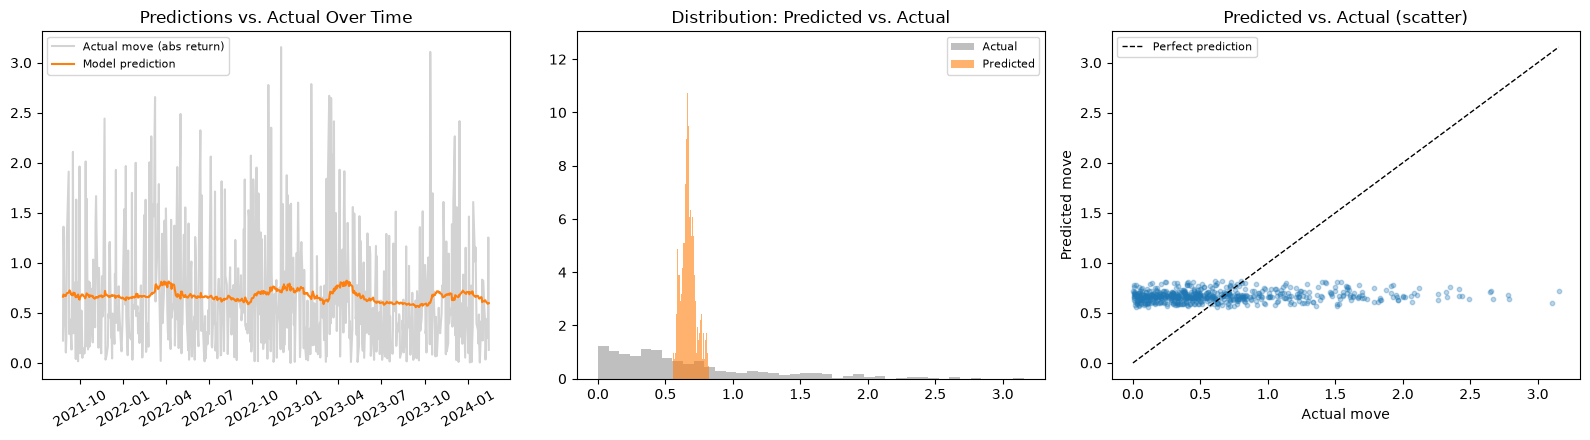

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Time series
axes[0].plot(dates_val, y_val, color="lightgray", label="Actual move (abs return)")
axes[0].plot(dates_val, predictions, color="tab:orange", label="Model prediction")
axes[0].set_title("Predictions vs. Actual Over Time")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis="x", rotation=30)

# 2. Distributions
axes[1].hist(y_val, bins=40, alpha=0.5, color="gray", label="Actual", density=True)
axes[1].hist(predictions, bins=40, alpha=0.6, color="tab:orange", label="Predicted", density=True)
axes[1].set_title("Distribution: Predicted vs. Actual")
axes[1].legend(fontsize=8)

# 3. Scatter
axes[2].scatter(y_val, predictions, alpha=0.3, s=10, color="tab:blue")
axes[2].plot([0, y_val.max()], [0, y_val.max()], color="black", linestyle="--", linewidth=1, label="Perfect prediction")
axes[2].set_xlabel("Actual move")
axes[2].set_ylabel("Predicted move")
axes[2].set_title("Predicted vs. Actual (scatter)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()